# Data Overview

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('aduhiyaiya.csv')
df.head()

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,...,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location
0,50154497,ELEMENTS PIZZERIA,Queens,83-01,NORTHERN BOULEVARD,11372.0,7187178753,Other,03/17/2025,Violations were cited in the following area(s).,...,Pre-permit (Operational) / Initial Inspection,40.755672,-73.884302,403.0,25.0,32700.0,4034565.0,4.014130e+09,QN28,POINT (-73.884301541496 40.755671854486)
1,50064466,LOCO COCO,Manhattan,835,LEXINGTON AVENUE,10065.0,9178156900,"Juice, Smoothies, Fruit Salads",06/22/2023,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,40.765142,-73.966041,108.0,4.0,12000.0,1042115.0,1.013980e+09,MN40,POINT (-73.966040729158 40.76514242275)
2,50158097,APU KENNEDY FRIED CHICKEN,Queens,127-07,MERRICK BOULEVARD,11434.0,3475458925,Chicken,03/17/2025,Violations were cited in the following area(s).,...,Pre-permit (Operational) / Re-inspection,40.681516,-73.765346,412.0,27.0,36600.0,4269971.0,4.124880e+09,QN08,POINT (-73.765345858131 40.681515758941)
3,50172767,FRESH BAKERY & SWEETS,Queens,37-15,73 STREET,11372.0,7182551445,Bakery Products/Desserts,01/09/2026,Violations were cited in the following area(s).,...,Administrative Miscellaneous / Re-inspection,40.748426,-73.892622,403.0,25.0,28900.0,4518723.0,4.012848e+09,QN28,POINT (-73.892622308314 40.748425534989)
4,50181605,YOSHI NY INC.,Brooklyn,2,HAVEMEYER STREET,11211.0,6469610218,NaN,01/01/1900,NaN,...,NaN,40.716484,-73.952783,301.0,33.0,51900.0,3061846.0,3.023140e+09,BK73,POINT (-73.95278333642 40.716484059461)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 296766 entries, 0 to 296765
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   CAMIS                  296766 non-null  int64  
 1   DBA                    296764 non-null  str    
 2   BORO                   296766 non-null  str    
 3   BUILDING               295807 non-null  str    
 4   STREET                 296765 non-null  str    
 5   ZIPCODE                293576 non-null  float64
 6   PHONE                  296752 non-null  str    
 7   CUISINE DESCRIPTION    293485 non-null  str    
 8   INSPECTION DATE        296766 non-null  str    
 9   ACTION                 293485 non-null  str    
 10  VIOLATION CODE         291191 non-null  str    
 11  VIOLATION DESCRIPTION  291190 non-null  str    
 12  CRITICAL FLAG          296766 non-null  str    
 13  SCORE                  280188 non-null  float64
 14  GRADE                  146385 non-null  str    

In [4]:
df.columns

Index(['CAMIS', 'DBA', 'BORO', 'BUILDING', 'STREET', 'ZIPCODE', 'PHONE',
       'CUISINE DESCRIPTION', 'INSPECTION DATE', 'ACTION', 'VIOLATION CODE',
       'VIOLATION DESCRIPTION', 'CRITICAL FLAG', 'SCORE', 'GRADE',
       'GRADE DATE', 'RECORD DATE', 'INSPECTION TYPE', 'Latitude', 'Longitude',
       'Community Board', 'Council District', 'Census Tract', 'BIN', 'BBL',
       'NTA', 'Location'],
      dtype='str')

In [5]:
df.isna().sum()


CAMIS                         0
DBA                           2
BORO                          0
BUILDING                    959
STREET                        1
ZIPCODE                    3190
PHONE                        14
CUISINE DESCRIPTION        3281
INSPECTION DATE               0
ACTION                     3281
VIOLATION CODE             5575
VIOLATION DESCRIPTION      5576
CRITICAL FLAG                 0
SCORE                     16578
GRADE                    150381
GRADE DATE               159862
RECORD DATE                   0
INSPECTION TYPE            3281
Latitude                   1427
Longitude                  1427
Community Board            4590
Council District           4563
Census Tract               4563
BIN                        5836
BBL                        1427
NTA                        4590
Location                   4590
dtype: int64

In [6]:
df['GRADE'].value_counts()

GRADE
A    99093
B    18741
C    13763
N     9487
Z     4397
P      904
Name: count, dtype: int64

In [ ]:
iya = df[['SCORE', 'INSPECTION DATE']].groupby('INSPECTION DATE').mean().sort_values(by='SCORE', ascending=False).dropna()
iya.head(20)

,SCORE
INSPECTION DATE,
11/16/2025,98.000000
04/01/2019,94.000000
10/19/2025,87.000000
05/30/2019,86.266667
05/15/2018,82.444444
10/12/2019,76.000000
02/21/2020,70.166667
11/13/2009,68.000000
01/25/2020,68.000000


In [8]:
# Parse dates
for col in ["INSPECTION DATE", "GRADE DATE", "RECORD DATE"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Filter 3 tahun terakhir
record_date = df["RECORD DATE"].dropna().max()
start_date = record_date - pd.DateOffset(years=3)

df_recent = df[
    (df["INSPECTION DATE"].notna()) &
    (df["INSPECTION DATE"] >= start_date) &
    (df["INSPECTION DATE"] <= record_date)
].copy()

# Rapikan kolom
df_recent["SCORE"] = pd.to_numeric(df_recent["SCORE"], errors="coerce")
df_recent["BORO"] = df_recent["BORO"].replace("0", "Unknown")
df_recent["CRITICAL FLAG"] = df_recent["CRITICAL FLAG"].astype(str).str.strip().str.lower()
df_recent["VIOLATION CODE"] = df_recent["VIOLATION CODE"].astype(str).str.strip()

inspection_key = ["CAMIS", "INSPECTION DATE", "INSPECTION TYPE"]

# Inspection-level summary yang lebih valid
df_ins = (
    df_recent.groupby(inspection_key, as_index=False)
    .agg(
        DBA=("DBA", "first"),
        BORO=("BORO", "first"),
        BUILDING=("BUILDING", "first"),
        STREET=("STREET", "first"),
        ZIPCODE=("ZIPCODE", "first"),
        PHONE=("PHONE", "first"),
        CUISINE_DESCRIPTION=("CUISINE DESCRIPTION", "first"),
        ACTION=("ACTION", "first"),
        SCORE=("SCORE", "first"),
        GRADE=("GRADE", "first"),
        GRADE_DATE=("GRADE DATE", "first"),
        Latitude=("Latitude", "first"),
        Longitude=("Longitude", "first"),
        Community_Board=("Community Board", "first"),
        Council_District=("Council District", "first"),
        Census_Tract=("Census Tract", "first"),
        BIN=("BIN", "first"),
        BBL=("BBL", "first"),
        NTA=("NTA", "first"),
        violation_count=("VIOLATION CODE", lambda x: x.notna().sum()),
        critical_count=("CRITICAL FLAG", lambda x: (x == "critical").sum()),
        has_critical=("CRITICAL FLAG", lambda x: (x == "critical").any())
    )
)

df_ins

,CAMIS,INSPECTION DATE,INSPECTION TYPE,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE_DESCRIPTION,...,Longitude,Community_Board,Council_District,Census_Tract,BIN,BBL,NTA,violation_count,critical_count,has_critical
0,30075445,2023-08-01,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,...,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,2,True
1,30075445,2023-08-22,Cycle Inspection / Re-inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,...,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,1,True
2,30075445,2024-11-08,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,...,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,1,True
3,30075445,2026-02-27,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,...,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,2,1,True
4,30191841,2023-04-23,Cycle Inspection / Initial Inspection,D.J. REYNOLDS,Manhattan,351,WEST 57 STREET,10019.0,2122452912,Irish,...,-73.984310,104.0,3.0,13900.0,1026048.0,1.010480e+09,MN15,2,2,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77624,50181726,2026-02-11,Pre-permit (Non-operational) / Initial Inspection,ELECTRIC GRILL,Queens,41-18,38 STREET,11101.0,9292178365,Bakery Products/Desserts,...,-73.926419,402.0,26.0,17900.0,4003123.0,4.002160e+09,QN31,1,0,False
77625,50182075,2026-02-24,Pre-permit (Non-operational) / Initial Inspection,POPPY'S COMMISSARY,Brooklyn,189,COLUMBIA STREET,11231.0,6462637108,American,...,-74.002423,306.0,39.0,5100.0,3004081.0,3.003300e+09,BK33,0,0,False
77626,50182182,2026-02-27,Administrative Miscellaneous / Initial Inspection,AUNTIE ANNE'S,Manhattan,185,GREENWICH STREET,10007.0,5164501662,Bagels/Pretzels,...,-74.012084,101.0,1.0,1300.0,1089309.0,1.000580e+09,MN25,4,0,False
77627,50182182,2026-02-27,Pre-permit (Non-operational) / Initial Inspection,AUNTIE ANNE'S,Manhattan,185,GREENWICH STREET,10007.0,5164501662,Bagels/Pretzels,...,-74.012084,101.0,1.0,1300.0,1089309.0,1.000580e+09,MN25,4,2,True


In [9]:
df_ins[['SCORE', 'INSPECTION DATE', 'DBA']]

,SCORE,INSPECTION DATE,DBA
0,38.0,2023-08-01,MORRIS PARK BAKE SHOP
1,12.0,2023-08-22,MORRIS PARK BAKE SHOP
2,10.0,2024-11-08,MORRIS PARK BAKE SHOP
3,7.0,2026-02-27,MORRIS PARK BAKE SHOP
4,10.0,2023-04-23,D.J. REYNOLDS
...,...,...,...
77624,2.0,2026-02-11,ELECTRIC GRILL
77625,0.0,2026-02-24,POPPY'S COMMISSARY
77626,NaN,2026-02-27,AUNTIE ANNE'S
77627,42.0,2026-02-27,AUNTIE ANNE'S


# Visualisasi Data

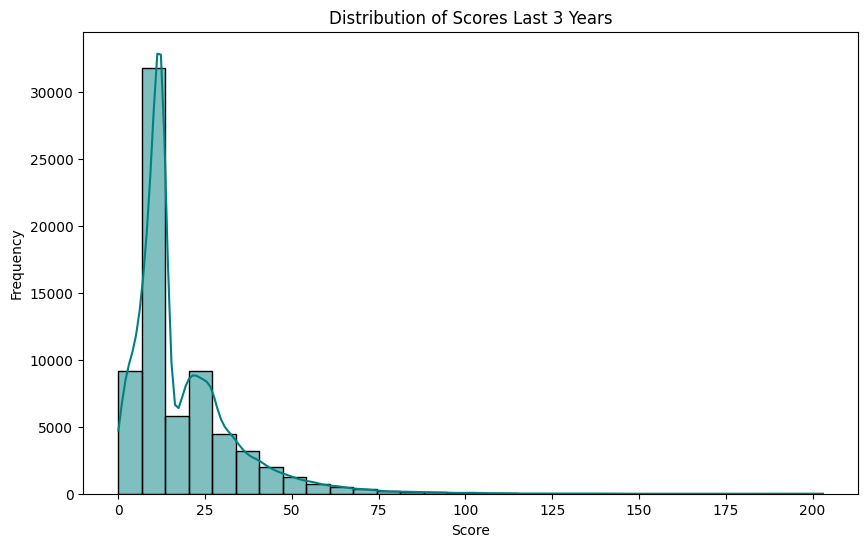

In [75]:
plt.figure(figsize=(10, 6))
sns.histplot(df_ins['SCORE'], bins=30, kde=True, color='teal', edgecolor='black')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Distribution of Scores Last 3 Years')
plt.show()


Histogram Distribusi SCORE selama 3 tahun terakhir
1. Distribusi terpusat di antara skor 0-25, menandakan tingkat kualitas yang cukup baik.
2. Terjadi penurunan signifikan dalam frekuensi skor di atas 25, menunjukkan tingkat kualitas yang lebih rendah.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12256\1065086977.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cuisine.index, y=top_cuisine.values, palette='viridis', ax=ax[0])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12256\1065086977.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=low_cuisine.index, y=low_cuisine.values, palette='viridis', ax=ax[1])


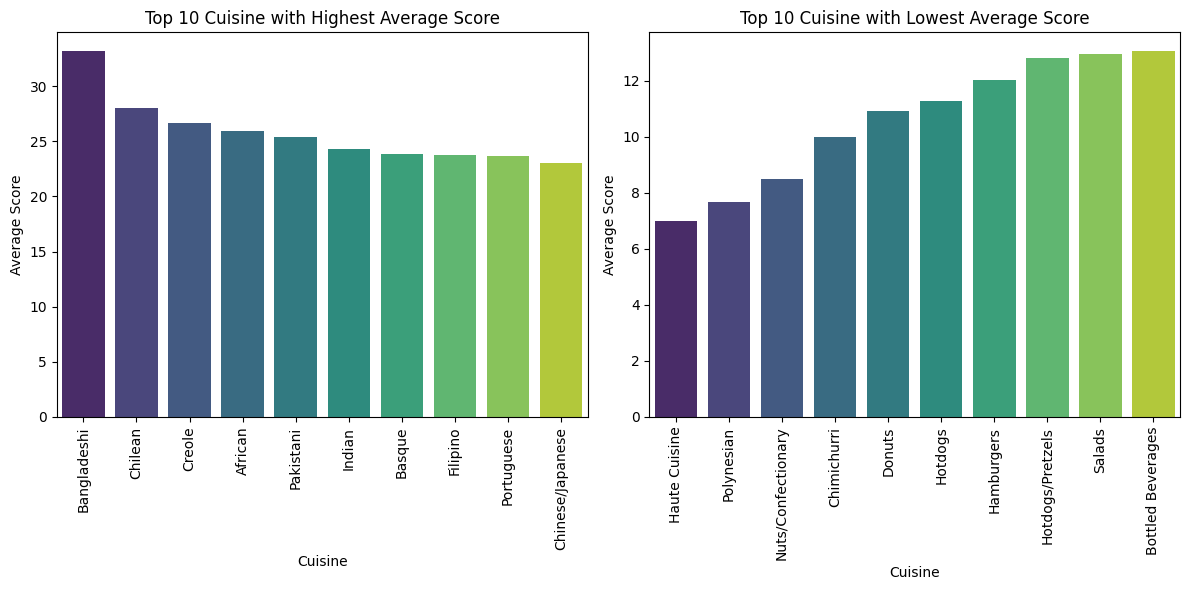

In [147]:
top_cuisine = df_ins.groupby('CUISINE_DESCRIPTION')['SCORE'].mean().sort_values(ascending=False).head(10)
low_cuisine = df_ins.groupby('CUISINE_DESCRIPTION')['SCORE'].mean().sort_values(ascending=True).head(10)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.barplot(x=top_cuisine.index, y=top_cuisine.values, palette='viridis', ax=ax[0])
ax[0].set_xlabel('Cuisine')
ax[0].tick_params(axis='x', rotation=90)
ax[0].set_ylabel('Average Score')
ax[0].set_title('Top 10 Cuisine with Highest Average Score')

sns.barplot(x=low_cuisine.index, y=low_cuisine.values, palette='viridis', ax=ax[1])
ax[1].set_xlabel('Cuisine')
ax[1].tick_params(axis='x', rotation=90)
ax[1].set_ylabel('Average Score')
ax[1].set_title('Top 10 Cuisine with Lowest Average Score')

plt.tight_layout()
plt.show()

Top 10 Cuisine dengan Skor Rata-Rata Tertinggi dan Terendah
1. Jenis makanan di area Asia Selatan (Bangladesh, Pakistan, dan India) seluruhnya menempati 10 jenis makanan dengan skor tertinggi.
2. Jenis makanan cepat saji atau kemasan cenderung memiliki skor yang rendah dibandingkan dengan jenis makanan yang lebih kompleks.
3. Bangladeshi adalah jenis makanan yang memiliki skor rata-rata tertinggi di antara semua jenis makanan.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12256\573931486.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=boro.index, y=boro.values, palette='inferno')


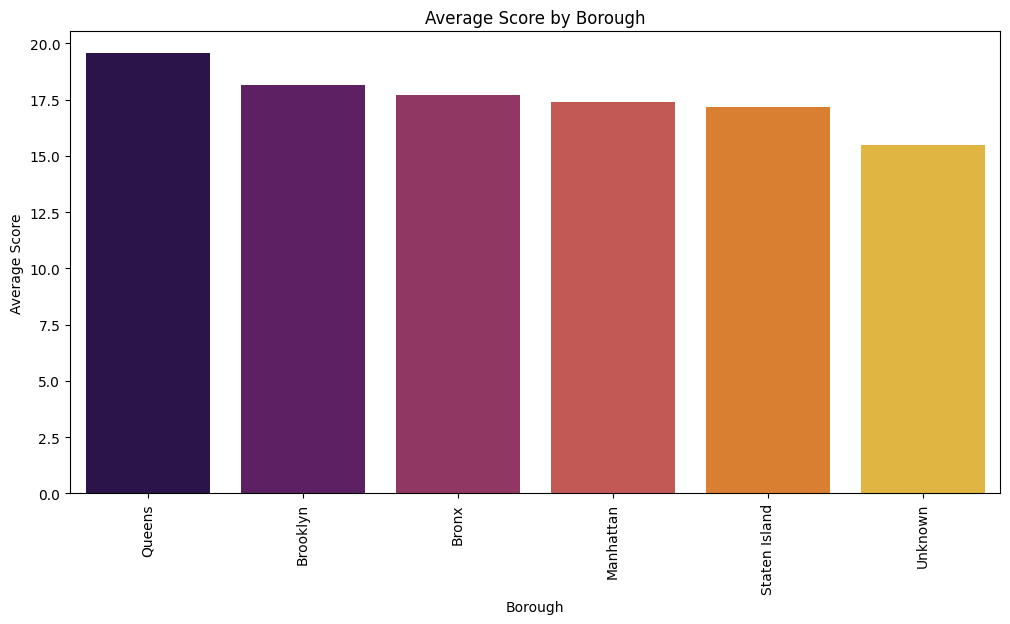

In [ ]:
boro = df_ins.groupby('BORO')['SCORE'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=boro.index, y=boro.values, palette='inferno')
plt.xticks(rotation=90)
plt.xlabel('Borough')
plt.ylabel('Average Score')
plt.title('Average Score by Borough')
plt.show()


Analisis Rata-Rata Skor pada BORO
1. Queens adalah boro dengan rata-rata skor tertinggi di antara semua boro.
2. Staten Island memiliki rata-rata skor terendah di antara semua boro.
3. Terdapat boro unknown yang cenderung memiliki rata-rata skor yang cukup tinggi

In [ ]:
monthly = df_ins.copy()
monthly['INSPECTION MONTH'] = monthly['INSPECTION DATE'].dt.month
monthly['INSPECTION QUARTER'] = monthly['INSPECTION DATE'].dt.quarter
dist_monthly = monthly.groupby('INSPECTION MONTH')['SCORE'].mean().reset_index(name='mean_score')
dist_monthly


,INSPECTION MONTH,mean_score
0,1,18.070890
1,2,17.348359
2,3,17.730051
3,4,17.748161
4,5,17.168442
5,6,18.005842
6,7,19.862485
7,8,19.589695
8,9,18.291943
9,10,18.048102


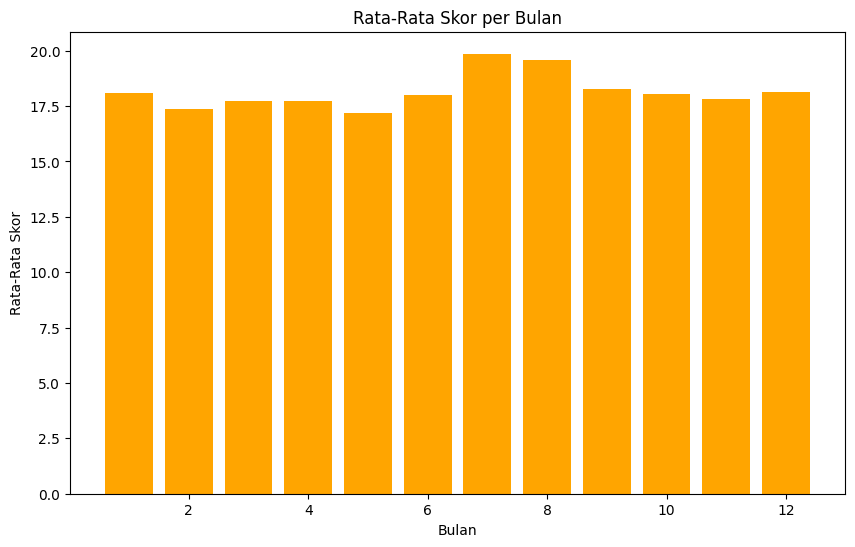

In [24]:
plt.figure(figsize=(10, 6))
plt.bar(x='INSPECTION MONTH', height='mean_score', data=dist_monthly, color='orange')
plt.title('Rata-Rata Skor per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Rata-Rata Skor')
plt.show()

Analisis Rata-Rata Skor per Bulan
1. Rata-rata skor per bulan menunjukkan fluktuasi yang cukup signifikan, dengan beberapa bulan memiliki rata-rata skor yang lebih tinggi daripada bulan lainnya.
2. Rata-rata skor per bulan memiliki tren naik selama tahun, dengan rata-rata skor tertinggi terjadi pada bulan Juli hingga Agustus.
3. Skor meningkat ketika kota New York sedang bermusim panas dibanding musim lainnya

In [25]:
dist_quarterly = monthly.groupby('INSPECTION QUARTER')['SCORE'].mean().reset_index(name='mean_score')
dist_quarterly


,INSPECTION QUARTER,mean_score
0,1,17.730756
1,2,17.614816
2,3,19.242606
3,4,18.015532


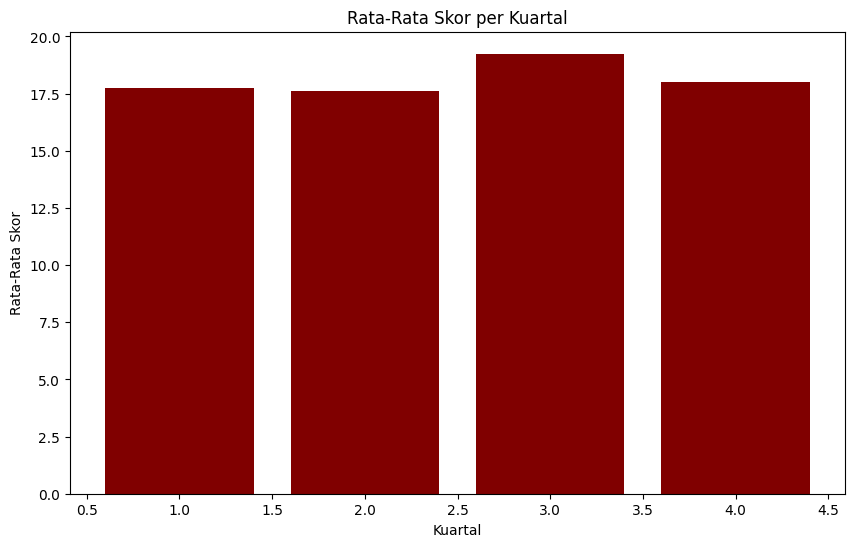

In [29]:
plt.figure(figsize=(10, 6))
plt.bar(x='INSPECTION QUARTER', height='mean_score', data=dist_quarterly, color='maroon')
plt.title('Rata-Rata Skor per Kuartal')
plt.xlabel('Kuartal')
plt.ylabel('Rata-Rata Skor')
plt.show()

Analisis Skor per Kuartal
1. Terdapat perbedaan skor pada kuartal 3 yang memiliki lonjakan skor dibanding kuartal 1 dan 2
2. Tejadi sedikit penurunan skor pada kuartal 4 dibandingkan dengan kuartal 3 namun tetap memiliki skor yang lebih tinggi dibandingkan dengan kuartal 1 dan 2

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12256\1035277081.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=ins_type.index, x=ins_type.values, palette='inferno')


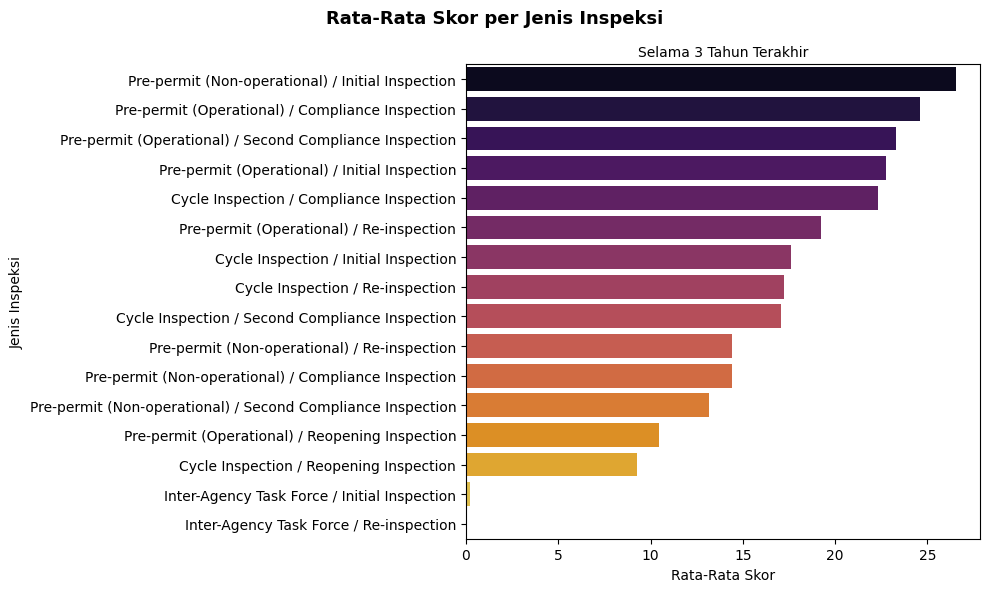

In [71]:
ins_type = (df_ins.dropna(subset=['INSPECTION TYPE', 'SCORE'])).groupby('INSPECTION TYPE')['SCORE'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(y=ins_type.index, x=ins_type.values, palette='inferno')
plt.suptitle('Rata-Rata Skor per Jenis Inspeksi', fontsize=13, fontweight='bold')
plt.title('Selama 3 Tahun Terakhir', fontsize=10)
plt.xlabel('Rata-Rata Skor')
plt.ylabel('Jenis Inspeksi')
plt.tight_layout()
plt.show()

Analisis Skor terhadap Jenis Inspeksi
1. Intial inspection pada bagian non-operational memiliki skor tertinggi dibandingkan dengan inspeksi lainnya
2. Bagian operational sendiri cenderung memiliki skor yang tinggi jika tipe inspeksinya berupa compliance inspection
3. Cycle inspection cenderung memiliki skor yang lebih rendah
4. Inter-Agency Task Force adalah jenis inspeksi dengan nilai paling rendah, kurang dari 5

In [82]:
df.columns

Index(['CAMIS', 'DBA', 'BORO', 'BUILDING', 'STREET', 'ZIPCODE', 'PHONE',
       'CUISINE DESCRIPTION', 'INSPECTION DATE', 'ACTION', 'VIOLATION CODE',
       'VIOLATION DESCRIPTION', 'CRITICAL FLAG', 'SCORE', 'GRADE',
       'GRADE DATE', 'RECORD DATE', 'INSPECTION TYPE', 'Latitude', 'Longitude',
       'Community Board', 'Council District', 'Census Tract', 'BIN', 'BBL',
       'NTA', 'Location'],
      dtype='str')

In [89]:
v_count = df.dropna(subset=['VIOLATION CODE', 'CRITICAL FLAG']).groupby('VIOLATION CODE')[['CRITICAL FLAG']].value_counts().reset_index(name='count').sort_values(by='count', ascending=False).head(10)
v_count

,VIOLATION CODE,CRITICAL FLAG,count
63,10F,Not Critical,41196
49,08A,Not Critical,27076
42,06D,Critical,18804
59,10B,Not Critical,18494
5,02G,Critical,18326
41,06C,Critical,18183
1,02B,Critical,15611
26,04L,Critical,15604
28,04N,Critical,11798
16,04A,Critical,8153


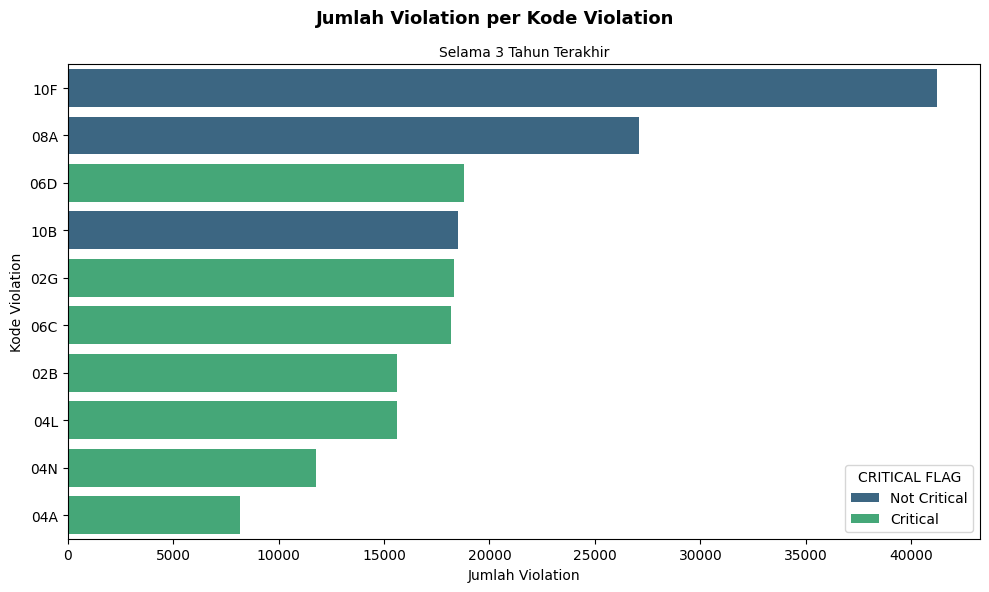

In [93]:
plt.figure(figsize=(10, 6))
sns.barplot(y=v_count['VIOLATION CODE'], x=v_count['count'], hue=v_count['CRITICAL FLAG'], palette='viridis')
plt.suptitle('Jumlah Violation per Kode Violation', fontsize=13, fontweight='bold')
plt.title('Selama 3 Tahun Terakhir', fontsize=10)
plt.xlabel('Jumlah Violation')
plt.ylabel('Kode Violation')
plt.tight_layout()
plt.show()

Analisis Jumlah Violation tiap Kode
1. Kode violation 10F adalah kode violation yang paling sering terjadi
2. Kode violation 06D adalah kode violation critical yang paling sering terjadi
3. Kebanyakan restoran justru lebih sering memiliki violation non-critical yang sama sedangkan pada critical lebih bervariasi

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12256\1616183594.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(y=top_vscore.index, x=top_vscore.values, size=12, palette='viridis', ax=ax[0])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12256\1616183594.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(y=bottom_vscore.index, x=bottom_vscore.values, size=12, palette='viridis', ax=ax[1])


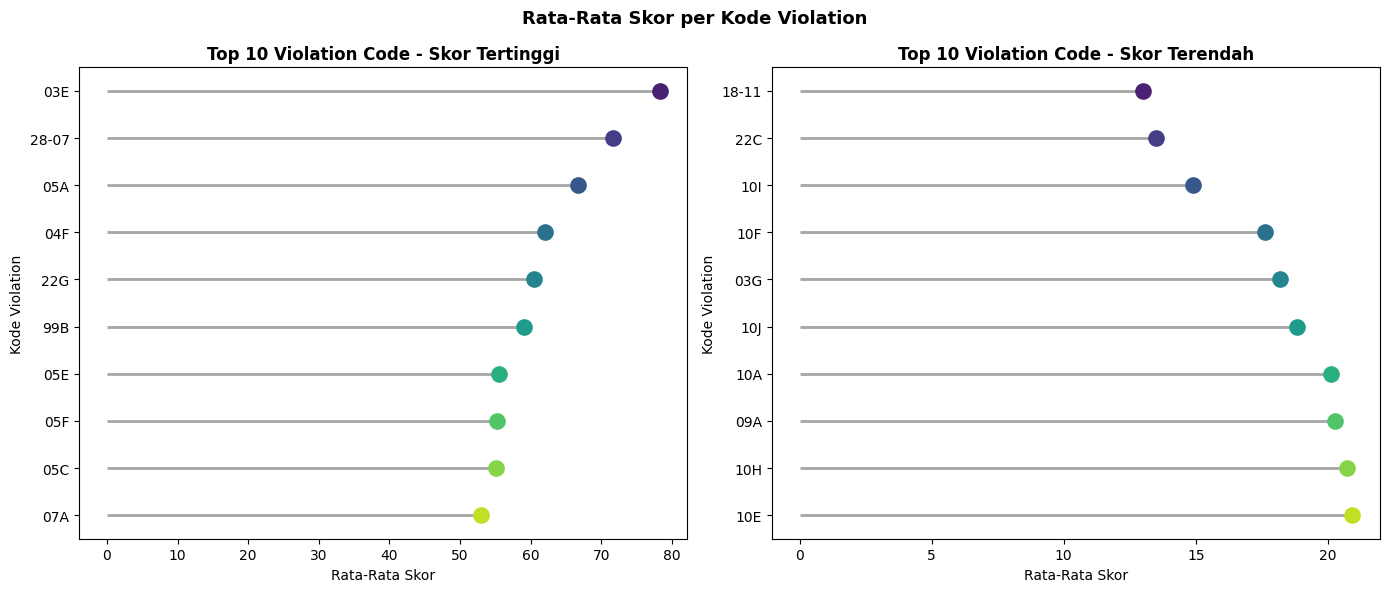

In [ ]:
top_vscore = (df.dropna(subset=['VIOLATION CODE', 'SCORE']).groupby('VIOLATION CODE')['SCORE'].mean().sort_values(ascending=False).head(10))
bottom_vscore = (df.dropna(subset=['VIOLATION CODE', 'SCORE']).groupby('VIOLATION CODE')['SCORE'].mean().sort_values(ascending=True).head(10))

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].hlines(y=top_vscore.index, xmin=0, xmax=top_vscore.values, color='gray', linewidth=2, alpha=0.7)
sns.stripplot(y=top_vscore.index, x=top_vscore.values, size=12, palette='viridis', ax=ax[0])
ax[0].set_title('Top 10 Violation Code - Skor Tertinggi', fontweight='bold')
ax[0].set_xlabel('Rata-Rata Skor')
ax[0].set_ylabel('Kode Violation')

ax[1].hlines(y=bottom_vscore.index, xmin=0, xmax=bottom_vscore.values, color='gray', linewidth=2, alpha=0.7)
sns.stripplot(y=bottom_vscore.index, x=bottom_vscore.values, size=12, palette='viridis', ax=ax[1])
ax[1].set_title('Top 10 Violation Code - Skor Terendah', fontweight='bold')
ax[1].set_xlabel('Rata-Rata Skor')
ax[1].set_ylabel('Kode Violation')

plt.suptitle('Rata-Rata Skor per Kode Violation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Analisis Skor terhadap Kode Violation
1. Kode violation 03E memiliki skor tertinggi dengan selisih yang cukup signifikan, berbeda hampir 10 poin dengan peringkat kedua
2. Kode violation 18-11 memiliki skor terendah dibandingkan dengan kode violation lainnya
3. Selisih skor tertinggi dan terendah kurang lebih 50-60 poin

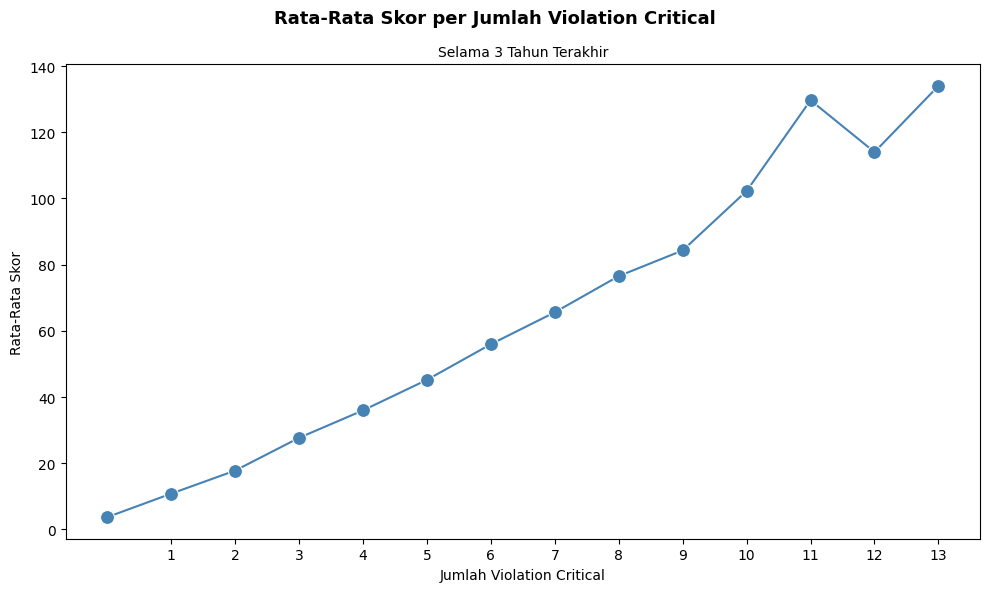

In [ ]:
is_critscore = df_ins.dropna(subset=['critical_count','SCORE']).groupby('critical_count')['SCORE'].mean()
plt.figure(figsize=(10, 6))
sns.lineplot(x=is_critscore.index, y=is_critscore.values, marker='o', markersize=10, color='steelblue')
plt.suptitle('Rata-Rata Skor per Jumlah Violation Critical', fontsize=13, fontweight='bold')
plt.title('Selama 3 Tahun Terakhir', fontsize=10)
plt.xlabel('Jumlah Violation Critical')
plt.ylabel('Rata-Rata Skor')
plt.xticks(range(1, 14))
plt.tight_layout()
plt.show()

Analisis Score terhadap Jumlah Critical Violation
1. Hubungan cenderung linear seiring bertambahnya jumlah critical violation, meningkat sekitar 10-15 poin tiap critical violation
2. Terdapat lonjakan drastis pada jumlah critical violation 11 ke 12, meningkat sekitar 30 poin
3. Setelah lonjakan, terjadi penurunan pada jumlah critical violation 12 ke 13

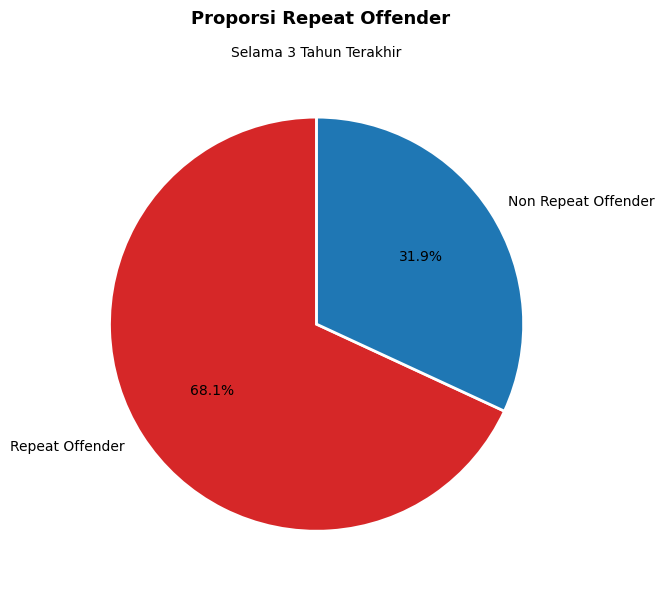

Repeat Offender : 18439 restoran
Non Repeat      : 8638 restoran
Total           : 27077 restoran


In [ ]:
total_camis = df_ins['CAMIS'].nunique()

repeat_offenders = (df_ins[df_ins['has_critical'] == True].groupby('CAMIS')['INSPECTION DATE'].nunique().reset_index(name='critical_count'))

jumlah_repeat = repeat_offenders[repeat_offenders['critical_count'] > 1]['CAMIS'].nunique()
jumlah_non_repeat = total_camis - jumlah_repeat

labels = ['Repeat Offender', 'Non Repeat Offender']
values = [jumlah_repeat, jumlah_non_repeat]

plt.figure(figsize=(8, 6))
plt.pie(values, labels=labels, autopct='%1.1f%%', colors=['#d62728', '#1f77b4'],startangle=90,wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.suptitle('Proporsi Repeat Offender', fontsize=13, fontweight='bold')
plt.title('Selama 3 Tahun Terakhir', fontsize=10)
plt.tight_layout()
plt.show()

Analisis Proporsi Repeat Offender
1. Lebih dari 68% dari total restoran yang ada merupakan restaurant repeat offender
2. Tingginya jumlah repeat offender menandakan mayoritas restoran tidak melakukan perbaikan setelah adanya inspeksi

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12256\4120422657.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=boro_repeat.values, y=boro_repeat.index, palette='Reds_r', ax=axes[0])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12256\4120422657.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cuisine_repeat.values, y=cuisine_repeat.index, palette='Reds_r', ax=axes[1])


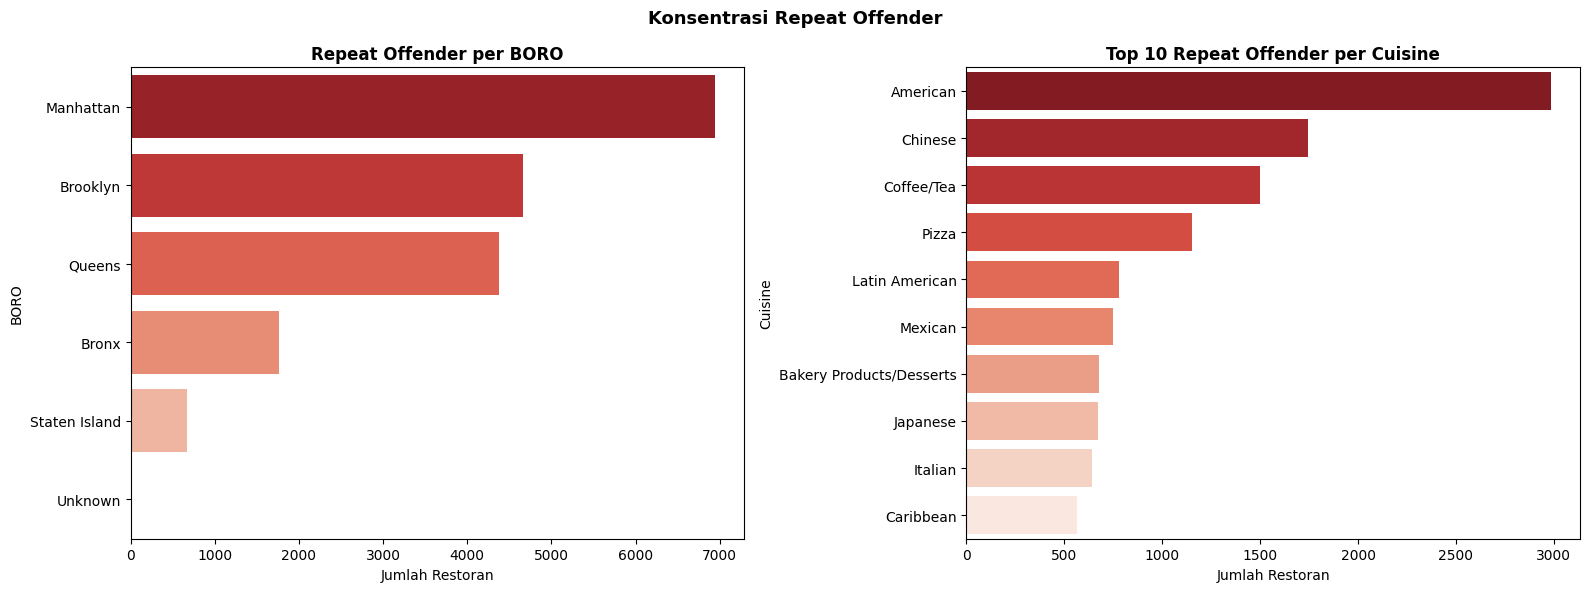

In [ ]:
repeat_offenders['is_repeat'] = repeat_offenders['critical_count'] > 1

df_repeat = df_ins.drop_duplicates(subset='CAMIS')[['CAMIS', 'BORO', 'CUISINE_DESCRIPTION']].merge(
    repeat_offenders, on='CAMIS', how='left'
)
df_repeat['is_repeat'] = df_repeat['is_repeat'].fillna(False)

boro_repeat = (df_repeat[df_repeat['is_repeat'] == True].groupby('BORO')['CAMIS'].count().sort_values(ascending=False))

cuisine_repeat = (df_repeat[df_repeat['is_repeat'] == True].groupby('CUISINE_DESCRIPTION')['CAMIS'].count().sort_values(ascending=False).head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=boro_repeat.values, y=boro_repeat.index, palette='Reds_r', ax=axes[0])
axes[0].set_title('Repeat Offender per BORO', fontweight='bold')
axes[0].set_xlabel('Jumlah Restoran')
axes[0].set_ylabel('BORO')

sns.barplot(x=cuisine_repeat.values, y=cuisine_repeat.index, palette='Reds_r', ax=axes[1])
axes[1].set_title('Top 10 Repeat Offender per Cuisine', fontweight='bold')
axes[1].set_xlabel('Jumlah Restoran')
axes[1].set_ylabel('Cuisine')

plt.suptitle('Konsentrasi Repeat Offender', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Analisis Konsentrasi Repeat Offender
1. Manhattan memiliki jumlah repeat offender tertinggi dengan selisih yang jauh, dapat dipengaruhi jumlah restoran yang ada
2. Staten Island memiliki jumlah repeat offender terendah, bisa saja karena memiliki jumlah restoran paling sedikit
3. Cuisine American mendominasi repeat offender, diikuti Chinese dan Coffee/Tea
4. Tingginya repeat offender pada American dan Chinese kemungkinan berkorelasi dengan jumlah restoran yang memang paling banyak di NYC

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12256\1785694240.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=boro_score.values, y=boro_score.index, palette='magma', ax=axes[0])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12256\1785694240.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=zip_score.values, y=zip_score.index.astype(str), palette='magma', ax=axes[1])


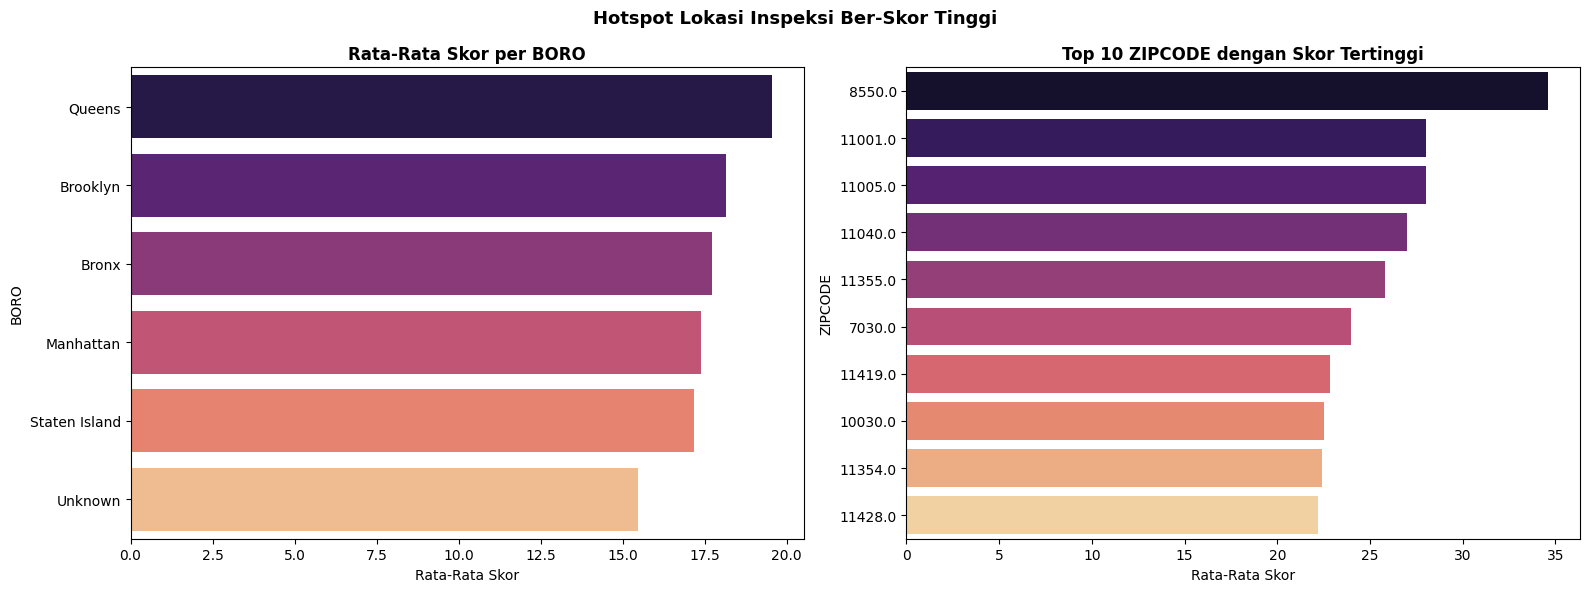

In [ ]:
boro_score = (df_ins.dropna(subset=['BORO', 'SCORE']).groupby('BORO')['SCORE'].mean().sort_values(ascending=False))

zip_score = (df_ins.dropna(subset=['ZIPCODE', 'SCORE']).groupby('ZIPCODE')['SCORE'].mean().sort_values(ascending=False).head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=boro_score.values, y=boro_score.index, palette='magma', ax=axes[0])
axes[0].set_title('Rata-Rata Skor per BORO', fontweight='bold')
axes[0].set_xlabel('Rata-Rata Skor')
axes[0].set_ylabel('BORO')

sns.barplot(x=zip_score.values, y=zip_score.index.astype(str), palette='magma', ax=axes[1])
axes[1].set_title('Top 10 ZIPCODE dengan Skor Tertinggi', fontweight='bold')
axes[1].set_xlabel('Rata-Rata Skor')
axes[1].set_ylabel('ZIPCODE')

plt.suptitle('Hotspot Lokasi Inspeksi Ber-Skor Tinggi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Analisis Hotspot dengan Skor Inspeksi
1. Queens memiliki rata-rata skor tertinggi di antara semua boro
2. Perbedaan skor antar boro relatif kecil, mengindikasikan pelanggaran yang cukup merata di seluruh NYC
3. ZIPCODE 8550 mencatat rata-rata skor tertinggi, jauh di atas ZIPCODE lainnya
4. Mayoritas ZIPCODE hotspot berawalan 110xx yang merupakan wilayah Queens

# Rangkuman Analisis Seluruh Visualisasi

1. Bagaimana distribusi SCORE selama 3 tahun terakhir?

Distribusi skor selama 3 tahun terakhir menunjukkan pola right-skewed, dengan mayoritas restoran terpusat di rentang skor 0–25. Hal ini mengindikasikan bahwa sebagian besar restoran di NYC berada pada kondisi sanitasi yang cukup baik dengan tingkat pelanggaran yang relatif rendah. Meskipun begitu, terdapat ekor distribusi yang memanjang ke kanan, menunjukkan adanya sebagian kecil restoran yang memiliki skor sangat tinggi dan tergolong bermasalah secara serius.

2. Apakah ada perubahan tren SCORE dari waktu ke waktu (per bulan/kuartal)?

Terdapat tren musiman yang cukup jelas dalam perubahan skor dari waktu ke waktu. Skor rata-rata menunjukkan fluktuasi yang signifikan antar bulan, dengan puncak tertinggi terjadi pada kuartal 3 yaitu Juli hingga Agustus yang mana bertepatan dengan musim panas NYC. Peningkatan skor di musim panas ini kemungkinan besar disebabkan oleh meningkatnya risiko kontaminasi makanan akibat suhu tinggi, meningkatnya aktivitas restoran di musim liburan, serta berkurangnya kewaspadaan pengelola restoran terhadap standar sanitasi. Memasuki kuartal 4, skor mengalami sedikit penurunan namun tetap berada di atas level kuartal 1 dan 2, mengindikasikan bahwa kondisi sanitasi belum sepenuhnya kembali ke standar awal tahun.

3. BORO mana yang cenderung memiliki SCORE lebih tinggi?


Queens tercatat sebagai boro dengan rata-rata skor tertinggi di antara semua boro di NYC, mengindikasikan bahwa restoran di wilayah ini secara rata-rata memiliki tingkat pelanggaran yang lebih berat dibanding wilayah lainnya. Di posisi berikutnya terdapat Brooklyn dan Bronx, sementara Manhattan dan Staten Island berada di bawah rata-rata. Staten Island menjadi boro dengan rata-rata skor terendah, yang kemungkinan berkaitan dengan kepadatan dan jumlah restoran yang lebih sedikit sehingga pengawasan lebih mudah dilakukan. Meski demikian, perbedaan antar boro secara keseluruhan relatif kecil, mengindikasikan bahwa masalah pelanggaran sanitasi bersifat merata di seluruh penjuru NYC dan bukan merupakan masalah yang terisolasi di wilayah tertentu saja.

4. Cuisine mana yang paling berisiko dan paling stabil?

Dari sisi risiko pelanggaran, restoran dengan latar belakang masakan Asia Selatan mendominasi 10 peringkat skor tertinggi. Bangladeshi menempati posisi pertama sebagai cuisine dengan rata-rata skor tertinggi, diikuti oleh Chilean dan Creole yang kemudian terdapat Pakistani dan Indian setelahnya. Dominasi masakan Asia Selatan di peringkat atas ini mengindikasikan adanya kemungkinan tantangan spesifik dalam memenuhi standar sanitasi DOHMH, yang mungkin berkaitan dengan kompleksitas bahan baku, teknik memasak, atau pemahaman terhadap regulasi yang berlaku. Di sisi lain, restoran yang menyajikan makanan cepat saji dan makanan kemasan cenderung memiliki skor lebih rendah, menandakan tingkat pelanggaran yang lebih ringan. Perbedaan keduanya mungkin cenderung disebabkam oleh kompleksitas produksi menjadi faktor utama sulitnya menangani standar sanitasi

5. Apakah tipe inspeksi tertentu cenderung menghasilkan SCORE lebih tinggi?

Tipe inspeksi memiliki pengaruh yang cukup signifikan terhadap skor yang dihasilkan. Non-operational initial inspection mencatat skor tertinggi di antara semua tipe inspeksi, mengindikasikan bahwa restoran yang diperiksa dalam kondisi tidak beroperasi cenderung ditemukan dalam kondisi yang lebih buruk. Pada segmen operational, compliance inspection cenderung menghasilkan skor yang lebih tinggi dibanding tipe lainnya, yang masuk akal mengingat compliance inspection biasanya dilakukan sebagai tindak lanjut dari pelanggaran sebelumnya. Cycle inspection sebagai inspeksi rutin cenderung menghasilkan skor lebih rendah, kemungkinan karena restoran sudah lebih siap menghadapi inspeksi berkala. Di sisi lain, Inter-Agency Task Force mencatat skor terendah dari semua tipe inspeksi bahkan di bawah angka 5, mengindikasikan bahwa inspeksi gabungan antar lembaga ini justru menemukan lebih sedikit pelanggaran atau dilakukan pada restoran yang memang sudah memiliki standar operasional yang lebih baik.

6. Violation code apa yang paling sering muncul?

Dari keseluruhan data inspeksi selama 3 tahun terakhir, kode violation 10F tercatat sebagai pelanggaran yang paling sering muncul secara keseluruhan, mengindikasikan bahwa jenis pelanggaran ini merupakan masalah yang sangat umum di kalangan restoran NYC. Untuk kategori critical violation, kode 06D menjadi yang paling sering ditemukan, menjadikannya sebagai prioritas utama yang perlu mendapat perhatian dari sisi pengawasan keamanan pangan. Jika dilihat dari peringkat 10 teratas, mayoritas pelanggarannya adalah pelanggaran critical yang menandakan restoran cenderung memiliki violation non-critical yang sama secara berulang, sementara jenis critical violation yang ditemukan lebih bervariasi antar restoran. 

7. Violation code mana yang paling terkait dengan SCORE tinggi?

Analisis rata-rata skor per kode violation mengungkapkan perbedaan yang sangat signifikan antar kode. Kode 03E mencatat rata-rata skor tertinggi dengan selisih yang cukup mencolok dengan hampir 10 poin di atas peringkat kedua yang mana mengindikasikan bahwa restoran yang terkena violation ini cenderung memiliki profil pelanggaran yang jauh lebih berat secara keseluruhan. Di ujung lain, kode 18-11 memiliki rata-rata skor terendah di antara semua kode violation. Rentang selisih antara skor tertinggi dan terendah antar kode mencapai 50–60 poin, yang merupakan perbedaan yang sangat besar dan mengindikasikan bahwa jenis violation tertentu berkaitan erat dengan kondisi sanitasi restoran yang jauh lebih buruk secara keseluruhan.

8. Apakah jumlah critical violation berhubungan dengan SCORE lebih tinggi?

Analisis hubungan antara jumlah critical violation dan skor menunjukkan pola yang cukup jelas dan konsisten. Terdapat hubungan positif yang cenderung linear pada setiap penambahan satu critical violation rata-rata meningkatkan skor sebesar 10–15 poin, yang mengkonfirmasi bahwa critical violation memiliki bobot penalti yang signifikan dalam sistem penilaian inspeksi. Pola linear ini berlaku konsisten hingga angka 11 critical violation. Namun terjadi lonjakan yang sangat drastis pada critical violation ke-12, dengan peningkatan skor sekitar 30 poin sekaligus, mengindikasikan adanya kasus-kasus ekstrem atau jenis violation yang sangat berat pada kelompok ini. Setelah lonjakan tersebut, terjadi penurunan pada angka 13 yang kemungkinan besar bukan mencerminkan kondisi yang sebenarnya, melainkan akibat sedikitnya jumlah data pada kelompok dengan 13 critical violation.

9. Berapa proporsi repeat offender?

Hasil analisis menunjukkan angka yang cukup mengkhawatirkan dengan lebih dari 68% dari total restoran yang terdaftar tercatat sebagai repeat offender, yaitu restoran yang mendapatkan critical violation lebih dari satu kali dalam periode 3 tahun terakhir. Artinya, hanya sekitar 32% restoran yang berhasil menjaga kondisi sanitasinya agar tidak kembali mendapat critical violation setelah inspeksi pertama. Tingginya proporsi ini mengindikasikan bahwa mayoritas restoran tidak melakukan perbaikan yang signifikan dan berkelanjutan pasca inspeksi yang diakibatkan kurangnya kesadaran pihak restoran terhadap risiko pelanggaran inspeksi yang mereka lakukan.

10. Apakah repeat offender terkonsentrasi di BORO/cuisine tertentu?

Dari sisi BORO, repeat offender paling banyak terkonsentrasi di Manhattan dengan jumlah hampir mencapai 7.000 restoran, hampir dua kali lipat dibanding Brooklyn dan Queens yang berada di posisi kedua dan ketiga dengan jumlah yang relatif serupa di kisaran 4.500 restoran. Bronx dan Staten Island berada jauh di bawahnya, dengan Staten Island mencatat jumlah terendah yang kemungkinan berkorelasi dengan kepadatan restoran yang memang lebih sedikit. 

Dari sisi cuisine, American mendominasi dengan selisih yang sangat jauh sekitar 3.000 restoran dibanding Chinese di posisi kedua dengan sekitar 1.700 restoran, diikuti Coffee/Tea dan Pizza. Tingginya jumlah pada cuisine American dan Chinese kemungkinan besar berkorelasi langsung dengan jumlah restoran dari kedua cuisine tersebut yang memang paling banyak di NYC.

11. Apakah ada hotspot lokasi inspeksi ber-score tinggi?

Analisis spasial menunjukkan adanya konsentrasi pelanggaran yang cukup jelas di wilayah-wilayah tertentu. Dari tingkat boro, Queens konsisten muncul sebagai wilayah dengan rata-rata skor tertinggi, menjadikannya hotspot utama pelanggaran sanitasi restoran di NYC. Untuk area yang lebih detail, ZIPCODE 8550 mencatat rata-rata skor tertinggi sekitar 35 poin, jauh melampaui wilayah lainnya dan hampir dua kali lipat rata-rata boro mana pun — mengindikasikan adanya konsentrasi restoran bermasalah yang sangat tinggi di wilayah tersebut. Mayoritas ZIPCODE yang masuk dalam daftar hotspot berawalan 110xx yang merupakan wilayah Queens, sehingga konsisten dengan temuan di level boro.